In [345]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
internal_PDC_VS_MPC_dir = os.getcwd()
internal_March_27_2026_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..'))
print(f'The current working directory is : {internal_PDC_VS_MPC_dir}')
internal_MPC_data_dir = os.path.abspath(os.path.join(internal_March_27_2026_dir, 'March27_2026'))
print(f'The MPC data directory : {internal_MPC_data_dir}')
internal_PD_data_dir = os.path.abspath(os.path.join(internal_March_27_2026_dir, 'March27_2026'))
print(f'The PD data directory : {internal_PD_data_dir}')
internal_VTR_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..', '..'))
print(f'The VTR directory : {internal_VTR_dir}')
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
print(f'The root directory : {root_dir}')
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
print(f'The internal HT directory : {internal_HT_dir}')
internal_HT_MPC_dir = os.path.abspath(os.path.join(internal_HT_dir, '2_MPC_Controllers'))
print(f'The internal HT MPC directory : {internal_HT_MPC_dir}')
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_MPC_dir, 'scripts'))
print(f'The internal scripts directory : {internal_scripts_dir}')
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

The current working directory is : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026
The PD data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026
The VTR directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results
The root directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control
The internal HT directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\8_Hardware\Hardware_Testing
The internal HT MPC directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adapti

In [346]:
internal_PDC_CDP_data_dir = os.path.abspath(os.path.join(internal_PD_data_dir, 'Processed_Data_March27_PD'))
internal_MPC_CDP_data_dir = os.path.abspath(os.path.join(internal_MPC_data_dir, 'Processed_Data_March27_MPC'))
print(f'The PDC data directory : {internal_PDC_CDP_data_dir}')
print(f'The MPC data directory : {internal_MPC_CDP_data_dir}')

The PDC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026\Processed_Data_March27_PD
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026\Processed_Data_March27_MPC


In [347]:
# Print the names of the files in the PDC and MPC data directories to check if they are the same
print(f'PDC data files : {os.listdir(internal_PDC_CDP_data_dir)}')
print(f'MPC data files : {os.listdir(internal_MPC_CDP_data_dir)}')   
      

PDC data files : ['Data_Mar27_PD_10kph_CS1.csv', 'Data_Mar27_PD_10kph_CS2.csv', 'Data_Mar27_PD_10kph_CS3.csv', 'Data_Mar27_PD_5kph_CS3.csv', 'Data_Mar27_PD_CS1_5kmph.csv', 'Data_Mar27_PD_CS2_5kmph.csv']
MPC data files : ['Data_Mar27_MPC_10kph_CS1.csv', 'Data_Mar27_MPC_10kph_CS2.csv', 'Data_Mar27_MPC_10kph_CS3.csv', 'Data_Mar27_MPC_CS1.csv', 'Data_Mar27_MPC_CS2.csv', 'Data_Mar27_MPC_CS3.csv', 'Data_Mar27_MPC_CS4.csv']


In [348]:
PDC_data_list = []
for i in range(len(os.listdir(internal_PDC_CDP_data_dir))):
    PDC_data_list.append(pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, os.listdir(internal_PDC_CDP_data_dir)[i])))
    
MPC_data_list = []
for i in range(len(os.listdir(internal_MPC_CDP_data_dir))):
    MPC_data_list.append(pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, os.listdir(internal_MPC_CDP_data_dir)[i])))

In [349]:
# Print the column names of the first dataframe in PDC_data_list and MPC_data_list to check if they are the same
print(f'PDC data columns : {PDC_data_list[0].columns}')
print(f'MPC data columns : {MPC_data_list[0].columns}')

PDC data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration(m/s^2)',
       'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph',
       'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean',
       'Ego_Position_clean', 'Obs_Position_clean'],
      dtype='object')
MPC data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration(m/s^2)',
       'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph',
       'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean',
       'Ego_Acceleration_clean', 'Obs_Acceleration_clean',
       'Ego_Position_clean', 'Obs_Position_clean'],
      dtype='object')


## For 5Kmph

In [350]:
# Selecting the file name for both PDC and MPC to plot them together.
PDC_file_name = os.listdir(internal_PDC_CDP_data_dir)[4]    
MPC_file_name = os.listdir(internal_MPC_CDP_data_dir)[6]
print(f'Selected PDC file name : {PDC_file_name}')
print(f'Selected MPC file name : {MPC_file_name}')

Selected PDC file name : Data_Mar27_PD_CS1_5kmph.csv
Selected MPC file name : Data_Mar27_MPC_CS4.csv


PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Acceleration_clean', 'Obs_Acceleration_clean', 'Ego_Position_clean', 'Obs_Position_clean']


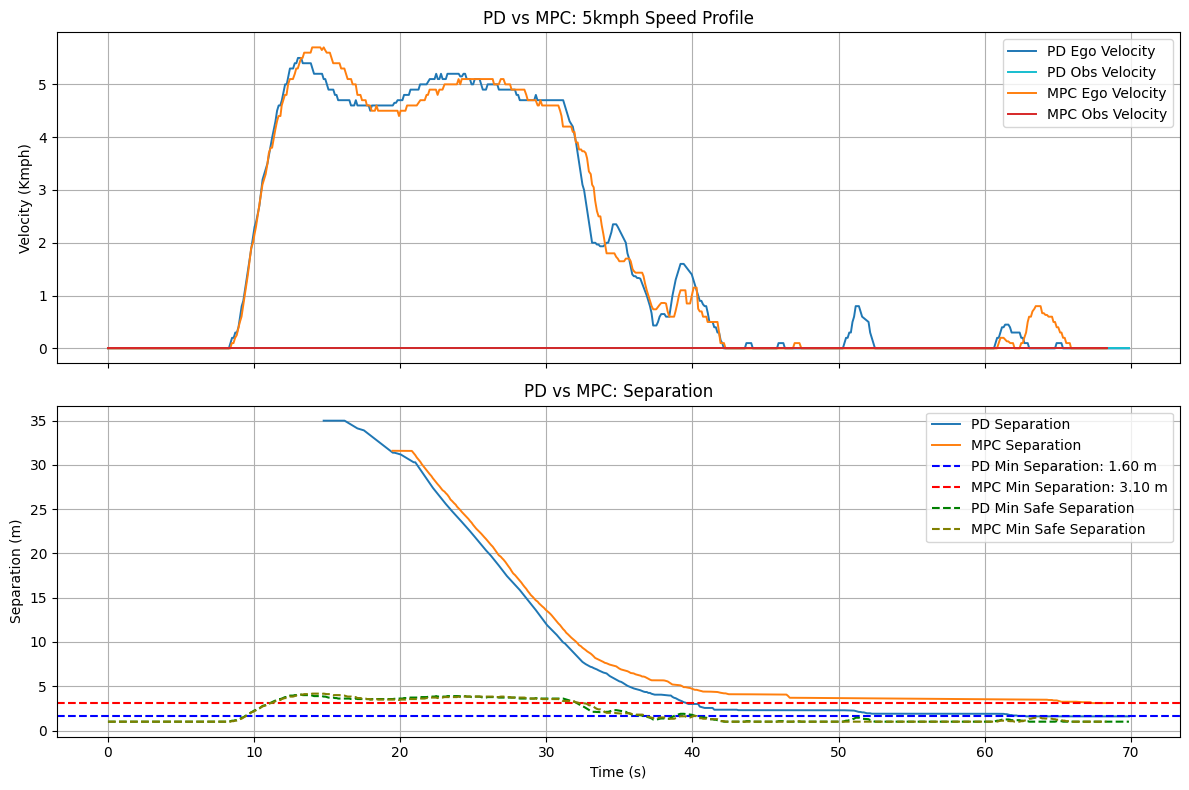

In [351]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, MPC_file_name))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:cyan", linewidth=1.4)
ax[0].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:orange", linewidth=1.4)
ax[0].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:red", linewidth=1.4)
ax[0].set_ylabel("Velocity (Kmph)")
ax[0].legend(loc="best")
ax[0].grid(True)
ax[0].set_title("PD vs MPC: 5kmph Speed Profile")

# Plot 2: Separation for PD and MPC
ax[1].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:orange", linewidth=1.4)
ax[1].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1].axhline(y=minimum_separation_mpc, color='red', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1].set_ylabel("Separation (m)")
ax[1].set_xlabel("Time (s)")
ax[1].legend(loc="best")
ax[1].grid(True)
ax[1].set_title("PD vs MPC: Separation")

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
legends = ax[1].get_legend_handles_labels()
by_label = dict(zip(legends[1], legends[0]))
ax[1].legend(by_label.values(), by_label.keys(), loc="best")

plt.tight_layout()
plt.show() 

PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Acceleration_clean', 'Obs_Acceleration_clean', 'Ego_Position_clean', 'Obs_Position_clean']


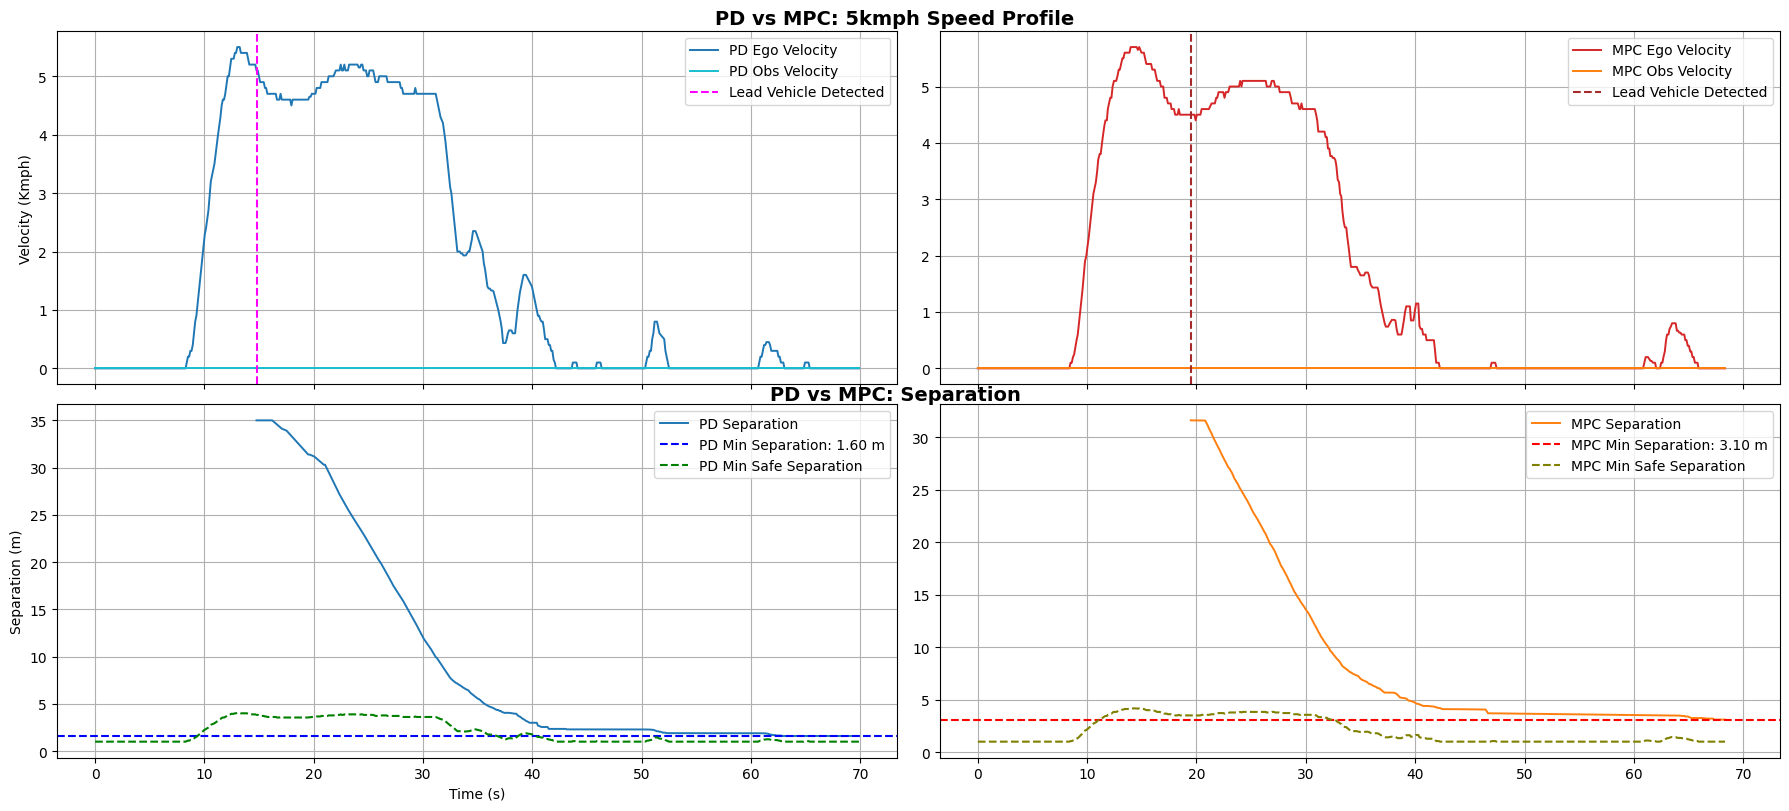

In [352]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, MPC_file_name))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(2, 2, figsize=(18, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0][0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0][0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:cyan", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:red", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:orange", linewidth=1.4)
ax[0][0].set_ylabel("Velocity (Kmph)")
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best")
ax[0][0].grid(True)
ax[0][1].grid(True)

# Plot the detection line at the point where the obstacle is detected (when separation starts decreasing from a large value)
detection_time_pd = pdc_df[pdc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
detection_time_mpc = mpc_df[mpc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
ax[0][0].axvline(x=detection_time_pd, color='magenta', linestyle='--', label= 'Lead Vehicle Detected')
ax[0][1].axvline(x=detection_time_mpc, color='brown', linestyle='--', label='Lead Vehicle Detected')
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best") 

# Plot 2: Separation for PD and MPC
ax[1][0].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1][1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:orange", linewidth=1.4)
ax[1][0].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1][1].axhline(y=minimum_separation_mpc, color='red', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1][0].set_ylabel("Separation (m)")
ax[1][0].set_xlabel("Time (s)")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")
ax[1][0].grid(True)
ax[1][1].grid(True)

fig.subplots_adjust(hspace=0.8)  # Reasonable spacing between rows
plt.tight_layout()

fig.text(0.5, 0.99, "PD vs MPC: 5kmph Speed Profile", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.52, "PD vs MPC: Separation", ha='center', fontsize=14, weight='bold')

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1][0].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1][1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")

plt.show() 

## For 10kmph

In [353]:
# Selecting the file name for both PDC and MPC to plot them together.
PDC_file_name = os.listdir(internal_PDC_CDP_data_dir)[0]    
MPC_file_name = os.listdir(internal_MPC_CDP_data_dir)[2]
print(f'Selected PDC file name : {PDC_file_name}')
print(f'Selected MPC file name : {MPC_file_name}')

Selected PDC file name : Data_Mar27_PD_10kph_CS1.csv
Selected MPC file name : Data_Mar27_MPC_10kph_CS3.csv


PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Acceleration_clean', 'Obs_Acceleration_clean', 'Ego_Position_clean', 'Obs_Position_clean']


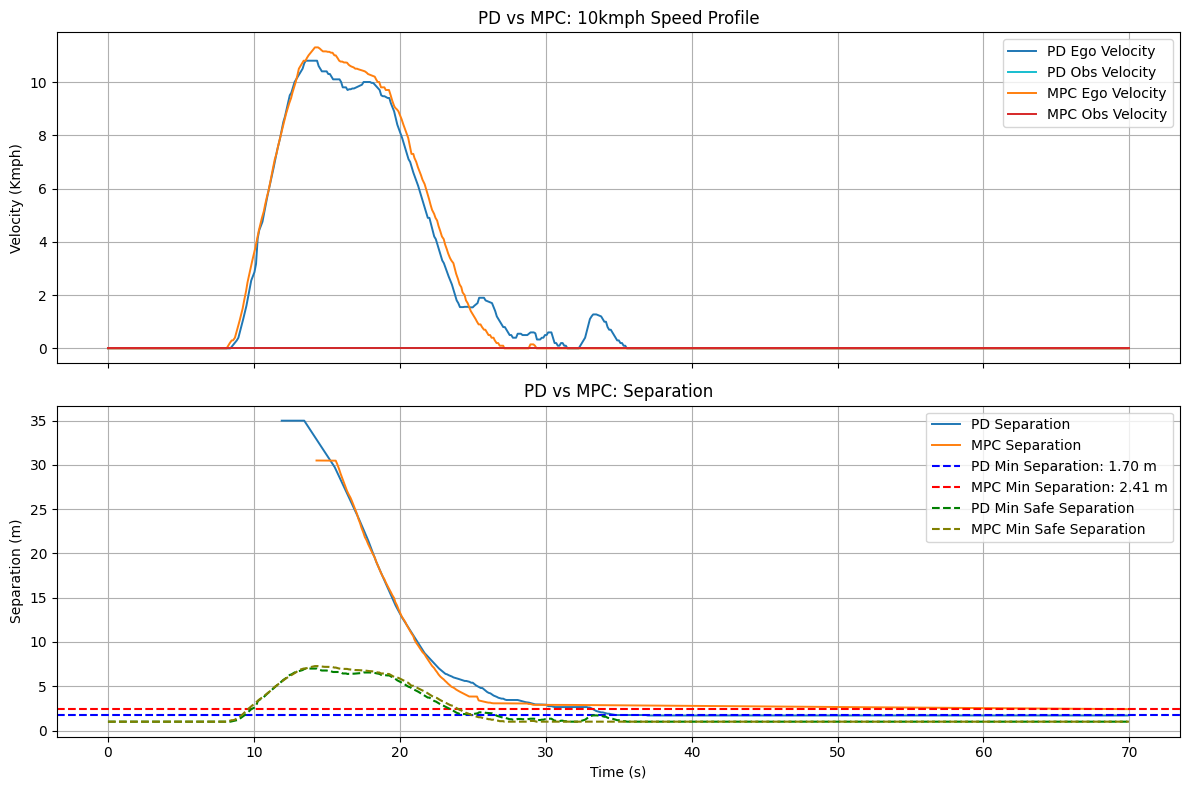

In [354]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, MPC_file_name))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:cyan", linewidth=1.4)
ax[0].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:orange", linewidth=1.4)
ax[0].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:red", linewidth=1.4)
ax[0].set_ylabel("Velocity (Kmph)")
ax[0].legend(loc="best")
ax[0].grid(True)
ax[0].set_title("PD vs MPC: 10kmph Speed Profile")


# Plot 2: Separation for PD and MPC
ax[1].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:orange", linewidth=1.4)
ax[1].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1].axhline(y=minimum_separation_mpc, color='red', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1].set_ylabel("Separation (m)")
ax[1].set_xlabel("Time (s)")
ax[1].legend(loc="best")
ax[1].grid(True)
ax[1].set_title("PD vs MPC: Separation")

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
legends = ax[1].get_legend_handles_labels()
by_label = dict(zip(legends[1], legends[0]))
ax[1].legend(by_label.values(), by_label.keys(), loc="best")

plt.tight_layout()
plt.show() 

PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Acceleration_clean', 'Obs_Acceleration_clean', 'Ego_Position_clean', 'Obs_Position_clean']


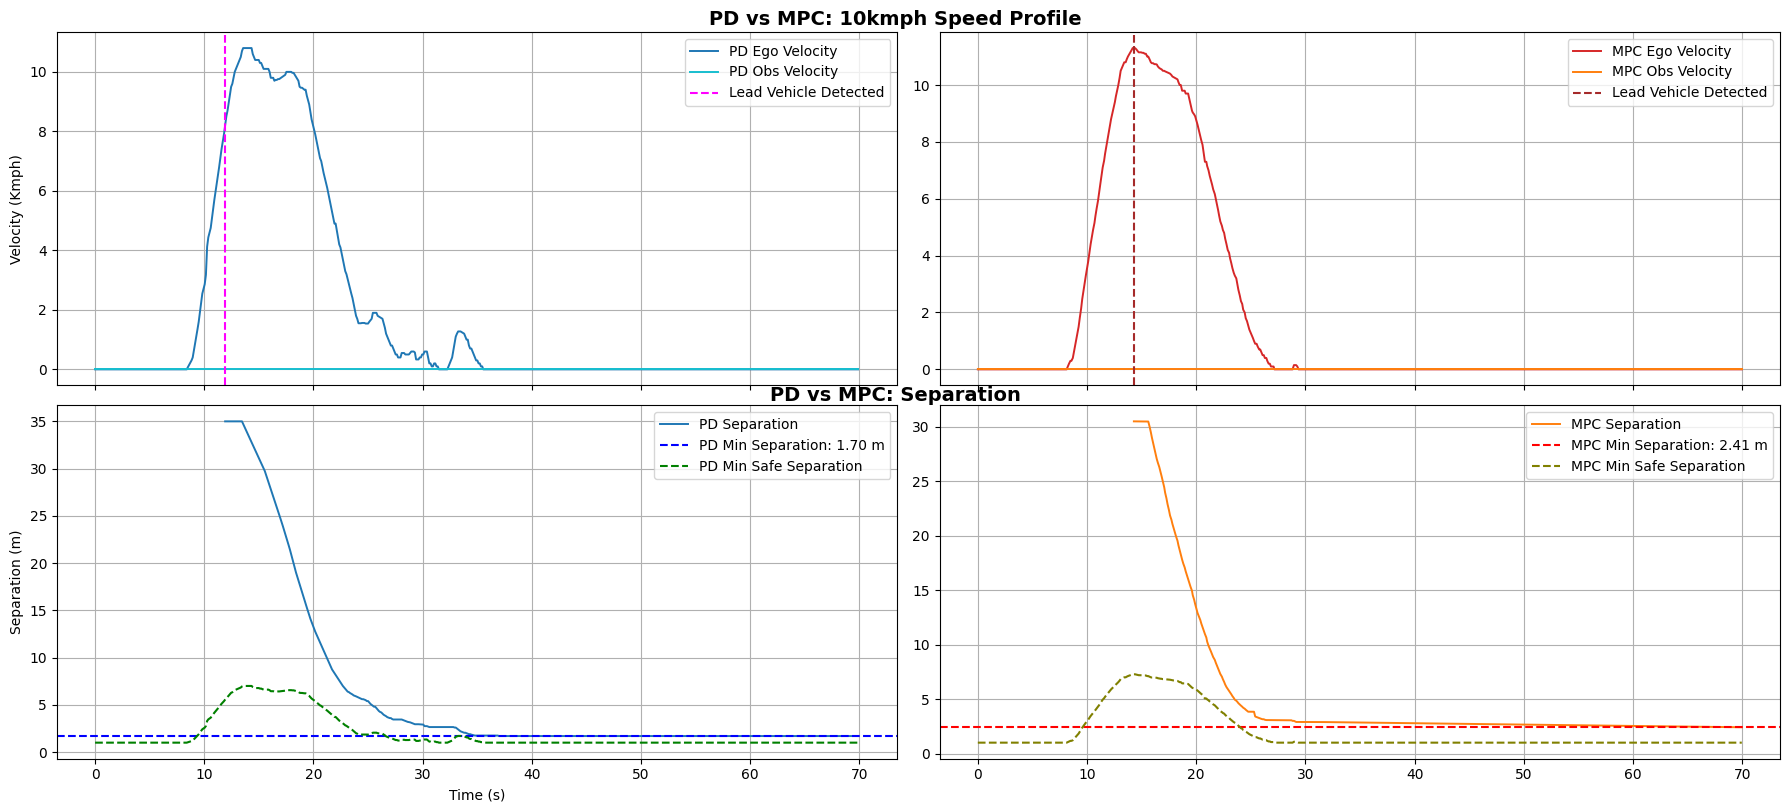

In [355]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, MPC_file_name))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(2, 2, figsize=(18, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0][0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0][0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:cyan", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:red", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:orange", linewidth=1.4)
ax[0][0].set_ylabel("Velocity (Kmph)")
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best")
ax[0][0].grid(True)
ax[0][1].grid(True)
# ax[0][0].set_title("PD vs MPC: 10kmph Speed Profile")

# Plot the detection line at the point where the obstacle is detected (when separation starts decreasing from a large value)
detection_time_pd = pdc_df[pdc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
detection_time_mpc = mpc_df[mpc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
ax[0][0].axvline(x=detection_time_pd, color='magenta', linestyle='--', label= 'Lead Vehicle Detected')
ax[0][1].axvline(x=detection_time_mpc, color='brown', linestyle='--', label='Lead Vehicle Detected')
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best") 

# Plot 2: Separation for PD and MPC
ax[1][0].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1][1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:orange", linewidth=1.4)
ax[1][0].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1][1].axhline(y=minimum_separation_mpc, color='red', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1][0].set_ylabel("Separation (m)")
ax[1][0].set_xlabel("Time (s)")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")
ax[1][0].grid(True)
ax[1][1].grid(True)
# ax[1][0].set_title("PD vs MPC: Separation")

fig.subplots_adjust(hspace=1)  # Reasonable spacing between rows
plt.tight_layout()

fig.text(0.5, 0.99, "PD vs MPC: 10kmph Speed Profile", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.52, "PD vs MPC: Separation", ha='center', fontsize=14, weight='bold')

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1][0].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1][1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")


plt.tight_layout()
plt.show() 